# Faster R-CNN 실습

## 1. 기본 환경 설정 및 라이브러리 설치

In [1]:
# Colab은 기본적으로 PyTorch와 TorchVision이 설치되어 있지만,
# 최신 버전의 engine, transforms 등을 사용하기 위해 업데이트를 권장

# Google Colab 환경에서 PyTorch와 TorchVision을 최신 버전으로 업데이트
# -U 옵션: 이미 설치된 패키지를 최신 버전으로 업그레이드
!pip install -U torch torchvision -q

# pycocotools: COCO 데이터셋 형식의 어노테이션을 다루기 위한 라이브러리
# Object Detection 모델 평가 시 필요한 mAP(mean Average Precision) 계산 등에 사용
!pip install pycocotools -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
# 시스템 관련 라이브러리
import os  # 파일 시스템 조작을 위한 라이브러리

# PyTorch 관련 라이브러리
import torch  # PyTorch 딥러닝 프레임워크
import torchvision  # PyTorch의 컴퓨터 비전 라이브러리

# Object Detection 모델 관련 라이브러리
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # Faster R-CNN의 분류기 헤드
from torchvision.io import read_image  # 이미지 파일을 읽어서 텐서로 변환하는 함수
from torchvision.utils import draw_bounding_boxes  # 이미지에 바운딩 박스를 그리는 유틸리티
from torchvision import transforms as T  # 이미지 전처리를 위한 변환 함수들

# 데이터 처리 및 시각화 라이브러리
import numpy as np  # 수치 계산을 위한 NumPy 라이브러리
from PIL import Image  # 이미지 처리를 위한 Pillow 라이브러리
import matplotlib.pyplot as plt  # 데이터 시각화를 위한 Matplotlib

# 설치된 PyTorch와 TorchVision의 버전 정보 출력
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.7.1+cu126
Torchvision Version: 0.22.1+cu126


In [3]:
# GPU 사용 가능 여부 확인
# CUDA는 NVIDIA GPU에서 병렬 처리를 위한 플랫폼
print("cuda (GPU) 사용 가능 여부:", torch.cuda.is_available())

# 장치 설정: GPU가 사용 가능하면 'cuda', 그렇지 않으면 'cpu' 사용
# GPU를 사용하면 모델 학습과 추론 속도가 크게 향상됨
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

cuda (GPU) 사용 가능 여부: True


In [4]:
# 이미지 시각화 함수
def show_image_with_boxes(img_tensor, boxes, title=""):
    """
    이미지 텐서와 바운딩 박스를 함께 시각화하는 함수

    Args:
        img_tensor: 표시할 이미지 텐서
        boxes: 바운딩 박스 좌표 리스트 (x1, y1, x2, y2 형식)
        title: 이미지 제목
    """
    # 텐서를 PIL 이미지로 변환
    img_to_show = T.ToPILImage()(img_tensor)

    # matplotlib으로 이미지 표시
    plt.imshow(img_to_show)
    ax = plt.gca()  # 현재 axes 객체 가져오기

    # 각 바운딩 박스를 빨간색 사각형으로 그리기
    for box in boxes:
        x, y, w, h = box[0], box[1], box[2]-box[0], box[3]-box[1]  # (x1,y1,x2,y2) -> (x,y,width,height)
        rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)  # 사각형을 axes에 추가

    plt.title(title)
    plt.axis('off')  # 축 눈금 제거
    plt.show()

## 2. 데이터셋 다운로드 및 준비

In [5]:
# -q 옵션: quiet 모드로 다운로드 과정의 출력을 숨김
!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -q

# 다운로드한 압축 파일을 PennFudanPed_data 폴더에 압축 해제
# -d 옵션: 압축 해제할 디렉토리 지정
# > /dev/null: 압축 해제 과정의 출력을 숨김
!unzip PennFudanPed.zip -d PennFudanPed_data > /dev/null

In [6]:
# 데이터셋 클래스
# 각종 데이터셋을 torch에서 관리하는 형태에 맞추어서 클래스 선언

class PennFudanDataset(torch.utils.data.Dataset):
    """
    PennFudanPed 데이터셋을 위한 커스텀 데이터셋 클래스
    보행자 감지를 위한 이미지와 어노테이션을 처리
    """

    def __init__(self, root, transforms):
        """
        데이터셋 초기화
        Args:
            root: 데이터셋의 루트 디렉토리 경로
            transforms: 이미지 전처리를 위한 변환 함수
        """
        self.root = root
        self.transforms = transforms
        # 이미지와 마스크 파일 경로를 정렬하여 매칭
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        """
        인덱스에 해당하는 이미지와 타겟 정보를 반환
        Args:
            idx: 데이터 인덱스
        Returns:
            img: 전처리된 이미지
            target: 바운딩 박스, 라벨 등의 타겟 정보를 담은 딕셔너리
        """
        # 이미지와 마스크 파일 경로 설정
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        # 이미지와 마스크 로드
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = np.array(mask)

        # 마스크에는 여러 객체(보행자)가 다른 색상으로 인코딩되어 있음
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[1:]  # 배경(0) 제외

        # 각 마스크를 바이너리 마스크로 분할
        # 각 객체(보행자)별로 별도의 마스크를 생성
        masks = mask == obj_ids[:, None, None]

        # 각 마스크로부터 바운딩 박스 계산
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            # 마스크에서 객체가 있는 픽셀의 위치를 찾음
            pos = np.where(masks[i])
            # 바운딩 박스의 최소/최대 좌표 계산
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # PyTorch 텐서로 변환
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # 클래스는 '보행자' 하나 뿐이므로 모두 1로 설정
        # (0은 배경을 의미하므로 보행자는 클래스 1)
        labels = torch.ones((num_objs,), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        # 이미지 ID (데이터셋 내에서 고유한 식별자)
        image_id = torch.tensor([idx])
        # 바운딩 박스의 면적 계산 (width * height)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # iscrowd는 여러 객체가 겹쳐있어 분리하기 어려운 경우를 의미
        # 이 데이터셋에서는 모든 객체를 False로 가정
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # 타겟 딕셔너리 구성 (Object Detection 모델이 기대하는 형식)
        target = {}
        target["boxes"] = boxes          # 바운딩 박스 좌표
        target["labels"] = labels        # 클래스 라벨
        # target["masks"] = masks        # Mask R-CNN을 학습시킨다면 이 라인 활성화
        target["image_id"] = image_id    # 이미지 ID
        target["area"] = area           # 바운딩 박스 면적
        target["iscrowd"] = iscrowd     # 군중 여부

        # 데이터 변환 적용 (전처리)
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        """데이터셋의 총 샘플 수 반환"""
        return len(self.imgs)

## 3. 모델 불러오기 및 사전 성능 확인
- 사전 학습된 Faster R-CNN 모델 불러오기

In [7]:
# COCO 데이터셋으로 사전 학습된 ResNet-50 백본을 사용하는 Faster R-CNN 모델
# FPN (Feature Pyramid Network): 다양한 크기의 객체를 잘 탐지하기 위한 구조
model_before = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)

# 모델을 GPU 또는 CPU로 이동
model_before.to(device)
# 평가 모드로 설정 (dropout, batch normalization 등을 평가 모드로 전환)
model_before.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 189MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
# 테스트용 데이터셋과 이미지 준비

dataset = PennFudanDataset('PennFudanPed_data/PennFudanPed', transforms=None)
img_tensor, _ = dataset[17]  # 17번 이미지를 테스트용으로 선택
img_tensor = T.ToTensor()(img_tensor).to(device)  # 이미지를 텐서로 변환하고 GPU/CPU로 이동

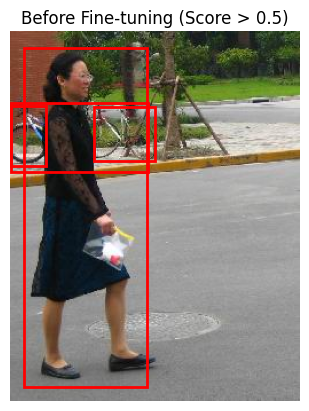

탐지된 객체 수: 4개


In [9]:
# 사전학습 모델의 기본 성능 테스트
# 모델의 gradient를 계산하지 않도록 설정 (추론 모드)
with torch.no_grad():
    # 모델에 이미지를 입력하여 예측 수행
    prediction = model_before([img_tensor])

# 결과 시각화를 위한 데이터 추출
boxes_before = prediction[0]['boxes']  # 바운딩 박스 좌표
scores_before = prediction[0]['scores']  # 각 박스의 신뢰도 점수
# 신뢰도(score)가 0.5 이상인 박스만 선택하여 노이즈 제거
filtered_boxes_before = boxes_before[scores_before > 0.5].cpu()

# 시각화 함수를 사용하여 결과 출력
show_image_with_boxes(
    img_tensor.cpu(),
    filtered_boxes_before,
    title="Before Fine-tuning (Score > 0.5)"
)
print(f"탐지된 객체 수: {len(filtered_boxes_before)}개")

-> 사전 학습이 되지 않아 잘못 탐지하는 점 확인 가능

## 4. Fine-Tuning을 위한 모델 및 데이터 준비

In [10]:
# 데이터 변환(Transform)을 위한 functional 모듈 import
# 이 모듈은 이미지 변환을 위한 low-level 함수들을 제공
from torchvision.transforms import functional as F

In [11]:
class Compose:
    """
    여러 개의 transform을 순차적으로 적용하는 클래스
    torchvision.transforms.Compose와 유사하지만 Object Detection용으로 커스터마이징
    """
    def __init__(self, transforms):
        """
        Args:
            transforms: 적용할 변환 함수들의 리스트
        """
        self.transforms = transforms

    def __call__(self, image, target):
        """
        이미지와 타겟에 모든 변환을 순차적으로 적용
        Args:
            image: 입력 이미지
            target: 바운딩 박스 등의 타겟 정보
        Returns:
            변환된 이미지와 타겟
        """
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

In [12]:
from torchvision import transforms as T
import torchvision.transforms.functional as F

class ToTensor:
    """
    PIL Image 또는 numpy array를 PyTorch 텐서로 변환하는 클래스
    Object Detection에서는 이미지만 변환하고 타겟 정보는 그대로 반환
    """
    def __call__(self, image, target):
        # PIL Image를 [0, 1] 범위의 PyTorch 텐서로 변환
        image = F.to_tensor(image)
        return image, target

In [13]:
# 데이터 증강 예시 (이미지에 수평 뒤집기를 확률적으로 수행)

import random

class RandomHorizontalFlip:
    """
    데이터 증강을 위한 랜덤 수평 뒤집기 클래스
    이미지와 바운딩 박스를 함께 수평으로 뒤집어 데이터의 다양성 증가
    """
    def __init__(self, prob):
        """
        Args:
            prob: 뒤집기가 적용될 확률 (0.0 ~ 1.0)
        """
        self.prob = prob

    def __call__(self, image, target):
        """
        지정된 확률로 이미지와 바운딩 박스를 수평으로 뒤집기
        """
        if random.random() < self.prob:
            # 이미지의 높이와 너비 가져오기
            height, width = image.shape[-2:]
            # 이미지를 수평으로 뒤집기 (마지막 차원에서 뒤집기)
            image = image.flip(-1)
            # 바운딩 박스 좌표 조정 (x 좌표를 뒤집기)
            bbox = target["boxes"]
            # x1, x2 좌표를 이미지 너비를 기준으로 뒤집기
            bbox[:, [0, 2]] = width - bbox[:, [2, 0]]
            target["boxes"] = bbox
            # 마스크가 있다면 마스크도 함께 뒤집기
            if "masks" in target:
                target["masks"] = target["masks"].flip(-1)
        return image, target

In [14]:
# 데이터 변환 적용
# 이미지에 다양한 변환을 가하면서 모델의 일반화 성능을 높일 수 있음

def get_transform(train):
    """
    학습/평가용 데이터 변환 함수를 반환
    Args:
        train: 학습 모드 여부 (True: 학습용, False: 평가용)
    Returns:
        Compose: 변환 함수들의 조합
    """
    transforms = []
    # 모든 경우에 PIL Image를 텐서로 변환
    transforms.append(ToTensor())
    # 학습 시에는 데이터 증강(Data Augmentation)을 위해 좌우 반전을 추가
    # 50% 확률로 이미지를 수평으로 뒤집어 데이터의 다양성을 증가시킴
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    return Compose(transforms)

In [15]:
# Fine-Tuning을 위한 모델 불러오기

def get_model_for_finetuning(num_classes):
    """
    Fine-tuning을 위한 Faster R-CNN 모델을 설정하는 함수

    Args:
        num_classes: 분류할 클래스 수 (배경 포함)
    Returns:
        model: Fine-tuning이 가능한 Faster R-CNN 모델
    """
    # COCO로 사전 학습된 Faster R-CNN 모델 로드
    # weights 파라미터를 통해 사전 학습된 가중치를 자동으로 다운로드하고 로드
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    # 분류기(classifier)의 입력 피처 수를 가져옴
    # roi_heads.box_predictor.cls_score: 클래스 분류를 위한 레이어
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # 사전 학습된 모델의 헤더를 새로운 헤더로 교체
    # num_classes는 배경(0) + 우리가 탐지할 클래스 수
    # 여기서는 배경 + 보행자 = 2
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [16]:
# 데이터셋과 데이터로더 준비

dataset = PennFudanDataset('PennFudanPed_data/PennFudanPed', get_transform(train=True))  # 학습용 데이터셋: 데이터 증강(augmentation) 적용
dataset_test = PennFudanDataset('PennFudanPed_data/PennFudanPed', get_transform(train=False))  # 테스트용 데이터셋: 데이터 증강 없이 기본 변환만 적용

In [17]:
torch.manual_seed(42)  # 재현 가능한 결과를 위해 시드 설정
indices = torch.randperm(len(dataset)).tolist()  # 데이터셋 인덱스를 무작위로 섞기

# 학습용 데이터와 테스트용으로 분리
dataset = torch.utils.data.Subset(dataset, indices[:-50])  # 마지막 50개를 제외한 데이터를 학습용으로 사용
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])  # 마지막 50개 데이터를 테스트용으로 사용

In [18]:
def collate_fn(batch):
    """
    배치 데이터를 처리하는 함수
    Object Detection에서는 이미지와 타겟의 크기가 다를 수 있으므로 커스텀 collate_fn이 필요
    """
    return tuple(zip(*batch))

# batch_size=2: 한 번에 2개의 이미지를 처리
# shuffle=True: 학습 시 데이터 순서를 랜덤하게 섞어서 과적합 방지
# num_workers=2: 데이터 로딩을 위한 병렬 프로세스 수

# 데이터로더 생성
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_fn)

# 테스트용 데이터로더는 섞지 않음 (일관된 평가를 위해)
data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=2, collate_fn=collate_fn)

In [19]:
# 모델 및 데이터로더 준비 완료 확인
print("모델 및 데이터로더 준비 완료")
print(f"\n학습 데이터: {len(dataset)}개, 테스트 데이터: {len(dataset_test)}개")

모델 및 데이터로더 준비 완료

학습 데이터: 120개, 테스트 데이터: 50개


## 5. Fine-Tuning 수행

In [20]:
# Fine-tuning을 위한 모델 준비

num_classes = 2 # 보행자 클래스 1개 + 배경 1개 = 총 2개 클래스
model_after = get_model_for_finetuning(num_classes) # Fine-tuning용 모델 생성 (마지막 분류 레이어가 우리 데이터에 맞게 수정됨)
model_after.to(device) # 모델을 GPU/CPU로 이동

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [22]:
# 옵티마이저(Optimizer) 설정
# 모델의 학습 가능한 파라미터만 추출 (requires_grad=True인 파라미터들)
params = [p for p in model_after.parameters() if p.requires_grad]

# SGD (Stochastic Gradient Descent) 옵티마이저 사용
# lr=0.005: 학습률 (learning rate) - 파라미터 업데이트의 크기 조절
# momentum=0.9: 모멘텀 - 이전 기울기 방향을 기억하여 더 빠른 수렴 도움
# weight_decay=0.0005: L2 정규화를 통한 과적합 방지
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# 학습률 스케줄러(Learning Rate Scheduler) 설정
# StepLR: 3 에폭마다 학습률을 0.1배로 감소시킴
# step_size=3: 3 에폭마다 스케줄 적용
# gamma=0.1: 학습률 감소 비율
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# 총 학습 에폭 수 설정
num_epochs = 10

In [23]:
for epoch in range(num_epochs):
    # 모델을 학습 모드로 설정 (dropout, batch normalization 등이 학습 모드로 전환)
    model_after.train()
    epoch_loss = 0  # 에폭별 손실 누적을 위한 변수

    # 데이터로더에서 배치 단위로 데이터를 불러와서 학습
    for images, targets in data_loader:
        # 이미지와 타겟을 GPU/CPU로 이동
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 모델에 이미지와 타겟을 입력하여 손실 계산
        # 학습 모드에서는 모델이 손실 딕셔너리를 반환
        loss_dict = model_after(images, targets)
        # 각 손실 값을 모두 합쳐서 전체 손실 계산
        losses = sum(loss for loss in loss_dict.values())

        # 역전파(backpropagation)를 위한 기울기 초기화
        optimizer.zero_grad()
        # 손실에 대한 역전파 수행 (기울기 계산)
        losses.backward()
        # 계산된 기울기를 사용하여 파라미터 업데이트
        optimizer.step()

        # 배치별 손실을 에폭 손실에 누적
        epoch_loss += losses.item()

    # 학습률 스케줄러 업데이트 (에폭 끝날 때마다)
    lr_scheduler.step()

    # 에폭별 평균 손실 출력
    print(f"Epoch #{epoch+1} Loss: {epoch_loss/len(data_loader):.4f}")

Epoch #1 Loss: 0.2794
Epoch #2 Loss: 0.1216
Epoch #3 Loss: 0.1191
Epoch #4 Loss: 0.0855
Epoch #5 Loss: 0.0735
Epoch #6 Loss: 0.0753
Epoch #7 Loss: 0.0679
Epoch #8 Loss: 0.0684
Epoch #9 Loss: 0.0685
Epoch #10 Loss: 0.0686


## 6. 성능 확인 및 비교

In [24]:
# 학습한 모델을 이용하여 추론 수행

model_after.eval()  # 학습이 완료된 모델을 평가 모드로 전환

img_tensor_test, _ = dataset_test.dataset[17]  # Fine-tuning 이전과 동일한 이미지로 테스트
img_tensor_test = img_tensor_test.to(device)  # 테스트 이미지를 GPU/CPU로 이동

In [25]:
# 모델의 gradient를 계산하지 않도록 설정 (추론 모드)
with torch.no_grad():
    # Fine-tuning된 모델로 동일한 이미지에 대해 예측 수행
    prediction_after = model_after([img_tensor_test])

# 결과 시각화를 위한 데이터 추출
boxes_after = prediction_after[0]['boxes']  # 바운딩 박스 좌표
scores_after = prediction_after[0]['scores']  # 각 박스의 신뢰도 점수
# 신뢰도(score)가 0.8 이상인 박스만 선택 (더 높은 임계값 사용)
filtered_boxes_after = boxes_after[scores_after > 0.8].cpu()

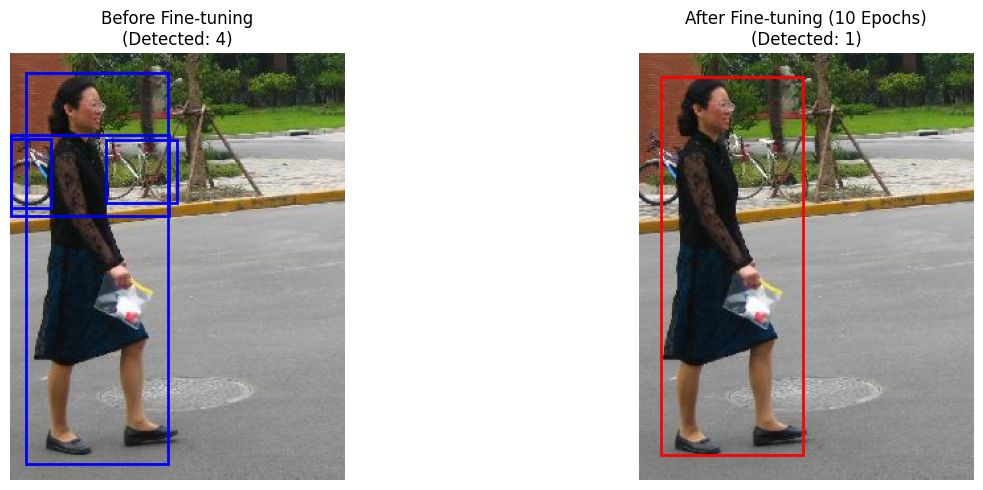

In [26]:
# Fine-Tuning을 통한 성능 향상 확인 시각화
plt.figure(figsize=(15, 5))

# Fine-tuning 이전 결과를 왼쪽에 표시
plt.subplot(1, 2, 1)
img_to_show_before = T.ToPILImage()(img_tensor_test.cpu())
plt.imshow(img_to_show_before)
ax1 = plt.gca()
# 탐지된 바운딩 박스를 파란색으로 그리기
for box in filtered_boxes_before:
    x, y, w, h = box[0], box[1], box[2]-box[0], box[3]-box[1]
    rect = plt.Rectangle((x, y), w, h, fill=False, color='blue', linewidth=2)
    ax1.add_patch(rect)
plt.title(f"Before Fine-tuning\n(Detected: {len(filtered_boxes_before)})")
plt.axis('off')

# Fine-tuning 이후 결과를 오른쪽에 표시
plt.subplot(1, 2, 2)
img_to_show_after = T.ToPILImage()(img_tensor_test.cpu())
plt.imshow(img_to_show_after)
ax2 = plt.gca()
# 탐지된 바운딩 박스를 빨간색으로 그리기
for box in filtered_boxes_after:
    x, y, w, h = box[0], box[1], box[2]-box[0], box[3]-box[1]
    rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
    ax2.add_patch(rect)
plt.title(f"After Fine-tuning (10 Epochs)\n(Detected: {len(filtered_boxes_after)})")
plt.axis('off')

# 서브플롯 간격 자동 조정
plt.tight_layout()
plt.show()

-> 학습한 결과에서는 사람만 정확하게 인식되는 것 확인 (Fine-Tuning을 통한 Object Detection 성능 향상)